**Setup MODEL - 1**

**CNN**

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
from src import config
from src.data import loader, preprocessing
from src.models.cnn import build_custom_cnn
from src.training.train import train_model
from src.evaluation import metrics, evaluation
from src.evaluation.confusion_matrix import plot_confusion_matrix

train_df, val_df, test_df = loader.create_splits()
train_ds = preprocessing.make_dataset(train_df, training=True)
val_ds = preprocessing.make_dataset(val_df)
test_ds = preprocessing.make_dataset(test_df)

**One-epoch test**

In [2]:
model = build_custom_cnn()
history_df, seconds = train_model(model, train_ds, val_ds, "custom_cnn", epochs=1)
print(f"1 epoch took {seconds/60:.1f} minutes")

D:\project\brain-tumor-detection\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


132/132 ━━━━━━━━━━━━━━━━━━━━ 290s 2s/step - accuracy: 0.4084 - loss: 1.2186 - val_accuracy: 0.4146 - val_loss: 1.1396 - learning_rate: 0.0010
1 epoch took 4.8 minutes


**Full training**

Epoch 1/20


D:\project\brain-tumor-detection\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


132/132 ━━━━━━━━━━━━━━━━━━━━ 288s 2s/step - accuracy: 0.4001 - loss: 1.2311 - val_accuracy: 0.3520 - val_loss: 1.3348 - learning_rate: 0.0010
Epoch 2/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.5458 - loss: 1.0133 - val_accuracy: 0.5740 - val_loss: 0.9770 - learning_rate: 0.0010
Epoch 3/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 290s 2s/step - accuracy: 0.5866 - loss: 0.9582 - val_accuracy: 0.4772 - val_loss: 1.1761 - learning_rate: 0.0010
Epoch 4/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - accuracy: 0.6075 - loss: 0.9271 - val_accuracy: 0.3975 - val_loss: 1.4032 - learning_rate: 0.0010
Epoch 5/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 286s 2s/step - accuracy: 0.6388 - loss: 0.8796 - val_accuracy: 0.4772 - val_loss: 1.2158 - learning_rate: 5.0000e-04
Epoch 6/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 334s 2s/step - accuracy: 0.6452 - loss: 0.8590 - val_accuracy: 0.5047 - val_loss: 1.1955 - learning_rate: 5.0000e-04
Epoch 7/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - accuracy: 0.6673 - loss: 0.833

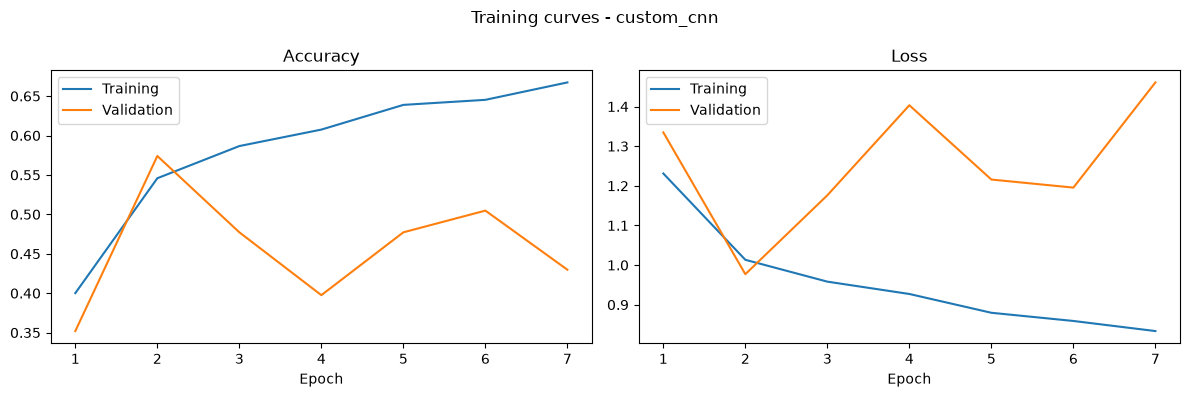

In [3]:
model = build_custom_cnn()      # fresh, untrained model
history_df, seconds = train_model(model, train_ds, val_ds, "custom_cnn")
print(f"Training took {seconds/60:.1f} minutes, {len(history_df)} epochs")
evaluation.plot_training_curves(history_df, "custom_cnn")

**Evaluation**

Validation: {'accuracy': 0.574, 'precision_macro': 0.578, 'recall_macro': 0.575, 'f1_macro': 0.536, 'roc_auc_ovr': 0.837}
Test:       {'accuracy': 0.565, 'precision_macro': 0.585, 'recall_macro': 0.565, 'f1_macro': 0.513, 'roc_auc_ovr': 0.808}
              precision    recall  f1-score   support

      glioma      0.607     0.453     0.519       400
  meningioma      0.616     0.113     0.190       400
     notumor      0.629     0.873     0.731       400
   pituitary      0.488     0.823     0.613       400

    accuracy                          0.565      1600
   macro avg      0.585     0.565     0.513      1600
weighted avg      0.585     0.565     0.513      1600



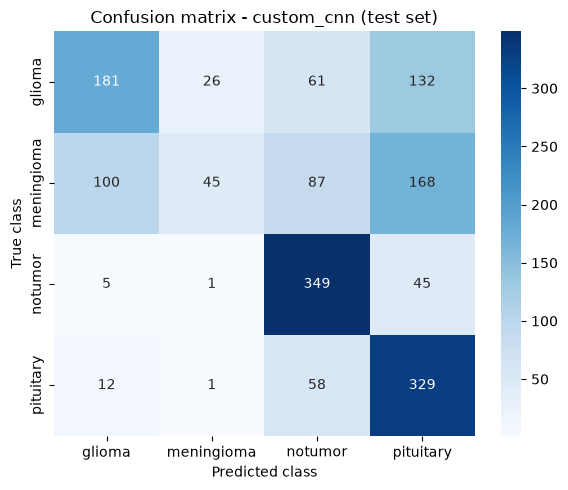

{'model': 'custom_cnn',
 'parameters': 110276,
 'training_time_seconds': 2192.6,
 'epochs_run': 7,
 'best_epoch': 2,
 'validation': {'accuracy': 0.5740037950664136,
  'precision_macro': 0.5783771508707897,
  'recall_macro': 0.5748789126783005,
  'f1_macro': 0.5359942372657118,
  'roc_auc_ovr': 0.836516647041466},
 'test': {'accuracy': 0.565,
  'precision_macro': 0.5851950747817506,
  'recall_macro': 0.565,
  'f1_macro': 0.5131131194748362,
  'roc_auc_ovr': 0.8081869791666667}}

In [4]:
y_val, pred_val, prob_val = metrics.predict_dataset(model, val_ds)
y_test, pred_test, prob_test = metrics.predict_dataset(model, test_ds)

val_metrics = metrics.compute_metrics(y_val, pred_val, prob_val)
test_metrics = metrics.compute_metrics(y_test, pred_test, prob_test)
print("Validation:", {k: round(v, 3) for k, v in val_metrics.items()})
print("Test:      ", {k: round(v, 3) for k, v in test_metrics.items()})
print(metrics.get_classification_report(y_test, pred_test))
plot_confusion_matrix(y_test, pred_test, "custom_cnn")

evaluation.save_results("custom_cnn", val_metrics, test_metrics, seconds,
                        history_df, model.count_params())

In [6]:
check = test_df.copy()
check["correct"] = (y_test == pred_test)
check["is_512"] = (check["width"] == 512) & (check["height"] == 512)
print(check.groupby("is_512")["correct"].agg(["mean", "count"]).round(3))
print()
print(check.groupby(["class", "is_512"])["correct"].agg(["mean", "count"]).round(3))

         mean  count
is_512              
False   0.592    598
True    0.549   1002

                    mean  count
class      is_512              
glioma     False   0.013     76
           True    0.556    324
meningioma False   0.000    117
           True    0.159    283
notumor    False   0.872    397
           True    1.000      3
pituitary  False   0.875      8
           True    0.821    392


**Resnet50**

In [8]:
from src.models.resnet import build_resnet50

model = build_resnet50()
model.summary()
history_df, seconds = train_model(model, train_ds, val_ds, "resnet50", epochs=1)
print(f"1 epoch took {seconds/60:.1f} minutes")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 20s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ augmentation (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet_preprocess (Normalization)    │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 4)                   │           8,196 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

D:\project\brain-tumor-detection\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


132/132 ━━━━━━━━━━━━━━━━━━━━ 1356s 10s/step - accuracy: 0.7278 - loss: 0.6901 - val_accuracy: 0.8283 - val_loss: 0.4595 - learning_rate: 0.0010
1 epoch took 22.6 minutes


Epoch 1/4


D:\project\brain-tumor-detection\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


132/132 ━━━━━━━━━━━━━━━━━━━━ 675s 5s/step - accuracy: 0.7473 - loss: 0.6646 - val_accuracy: 0.8197 - val_loss: 0.4773 - learning_rate: 0.0010
Epoch 2/4
132/132 ━━━━━━━━━━━━━━━━━━━━ 678s 5s/step - accuracy: 0.8548 - loss: 0.3917 - val_accuracy: 0.8691 - val_loss: 0.3976 - learning_rate: 0.0010
Epoch 3/4
132/132 ━━━━━━━━━━━━━━━━━━━━ 653s 5s/step - accuracy: 0.8685 - loss: 0.3535 - val_accuracy: 0.8643 - val_loss: 0.3915 - learning_rate: 0.0010
Epoch 4/4
132/132 ━━━━━━━━━━━━━━━━━━━━ 650s 5s/step - accuracy: 0.8847 - loss: 0.3129 - val_accuracy: 0.8776 - val_loss: 0.3308 - learning_rate: 0.0010
Training took 44.3 minutes, 4 epochs


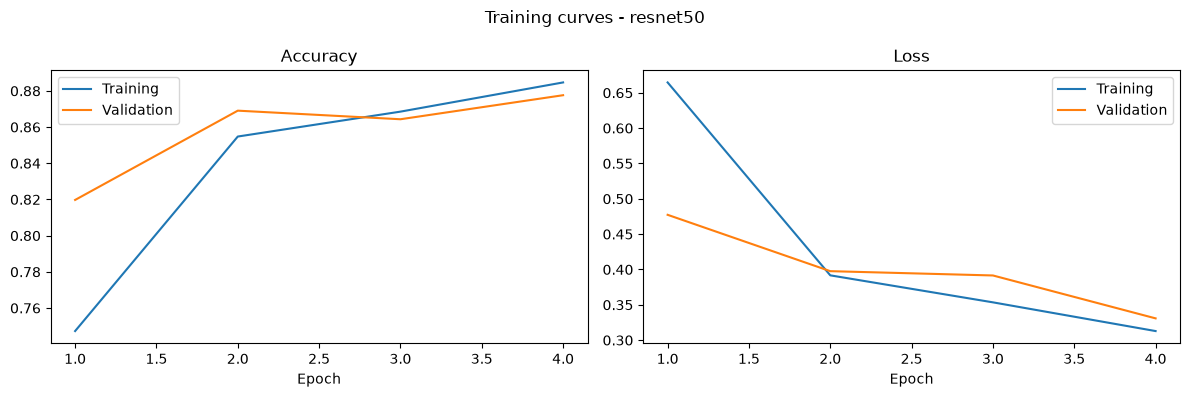

In [9]:
model = build_resnet50()          # fresh model
history_df, seconds = train_model(model, train_ds, val_ds, "resnet50", epochs=4)
print(f"Training took {seconds/60:.1f} minutes, {len(history_df)} epochs")
evaluation.plot_training_curves(history_df, "resnet50")

Validation: {'accuracy': 0.878, 'precision_macro': 0.876, 'recall_macro': 0.879, 'f1_macro': 0.877, 'roc_auc_ovr': 0.978}
Test:       {'accuracy': 0.811, 'precision_macro': 0.815, 'recall_macro': 0.811, 'f1_macro': 0.803, 'roc_auc_ovr': 0.953}
              precision    recall  f1-score   support

      glioma      0.900     0.698     0.786       400
  meningioma      0.750     0.600     0.667       400
     notumor      0.764     0.988     0.862       400
   pituitary      0.845     0.958     0.898       400

    accuracy                          0.811      1600
   macro avg      0.815     0.811     0.803      1600
weighted avg      0.815     0.811     0.803      1600



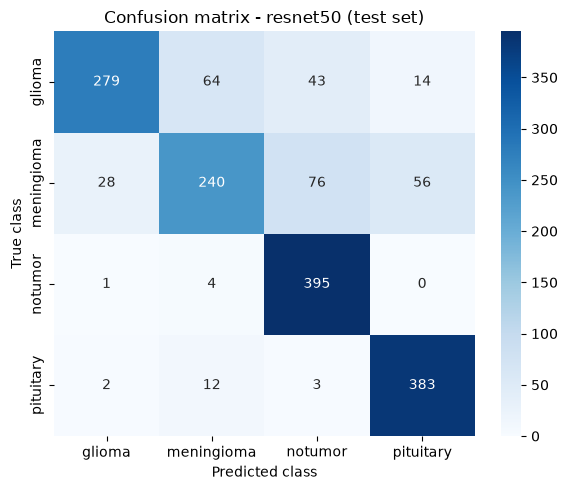

                    mean  count
class      is_512              
glioma     False   0.105     76
           True    0.836    324
meningioma False   0.128    117
           True    0.795    283
notumor    False   0.987    397
           True    1.000      3
pituitary  False   1.000      8
           True    0.957    392


In [10]:
MODEL_NAME = "resnet50"

y_val, pred_val, prob_val = metrics.predict_dataset(model, val_ds)
y_test, pred_test, prob_test = metrics.predict_dataset(model, test_ds)
val_metrics = metrics.compute_metrics(y_val, pred_val, prob_val)
test_metrics = metrics.compute_metrics(y_test, pred_test, prob_test)
print("Validation:", {k: round(v, 3) for k, v in val_metrics.items()})
print("Test:      ", {k: round(v, 3) for k, v in test_metrics.items()})
print(metrics.get_classification_report(y_test, pred_test))
plot_confusion_matrix(y_test, pred_test, MODEL_NAME)
evaluation.save_results(MODEL_NAME, val_metrics, test_metrics, seconds,
                        history_df, model.count_params())

check = test_df.copy()
check["correct"] = (y_test == pred_test)
check["is_512"] = (check["width"] == 512) & (check["height"] == 512)
print(check.groupby(["class", "is_512"])["correct"].agg(["mean", "count"]).round(3))

In [11]:
for name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    is_512 = (df["width"] == 512) & (df["height"] == 512)
    print(name)
    print(pd.crosstab(df["class"], is_512))
    print()

train
col_0       False  True 
class                   
glioma          0   1116
meningioma     21   1008
notumor       968     11
pituitary      39   1051

validation
col_0       False  True 
class                   
glioma          0    280
meningioma      9    249
notumor       242      2
pituitary      12    260

test
col_0       False  True 
class                   
glioma         76    324
meningioma    117    283
notumor       397      3
pituitary       8    392



**EfficientNetB0**

In [12]:
from src.models.efficientnet import build_efficientnet

model = build_efficientnet()
model.summary()
history_df, seconds = train_model(model, train_ds, val_ds, "efficientnet", epochs=1)
print(f"1 epoch took {seconds/60:.1f} minutes")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 19s 1us/step


Model: "efficientnet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)          │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ augmentation (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_4           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 4)                   │           5,124 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

D:\project\brain-tumor-detection\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


132/132 ━━━━━━━━━━━━━━━━━━━━ 278s 2s/step - accuracy: 0.7034 - loss: 0.7664 - val_accuracy: 0.7590 - val_loss: 0.5984 - learning_rate: 0.0010
1 epoch took 4.7 minutes


Epoch 1/6


D:\project\brain-tumor-detection\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


132/132 ━━━━━━━━━━━━━━━━━━━━ 284s 2s/step - accuracy: 0.7067 - loss: 0.7662 - val_accuracy: 0.7467 - val_loss: 0.6270 - learning_rate: 0.0010
Epoch 2/6
132/132 ━━━━━━━━━━━━━━━━━━━━ 287s 2s/step - accuracy: 0.8382 - loss: 0.4653 - val_accuracy: 0.7713 - val_loss: 0.5864 - learning_rate: 0.0010
Epoch 3/6
132/132 ━━━━━━━━━━━━━━━━━━━━ 250s 2s/step - accuracy: 0.8510 - loss: 0.4221 - val_accuracy: 0.7742 - val_loss: 0.5807 - learning_rate: 0.0010
Epoch 4/6
132/132 ━━━━━━━━━━━━━━━━━━━━ 259s 2s/step - accuracy: 0.8681 - loss: 0.3749 - val_accuracy: 0.8065 - val_loss: 0.5324 - learning_rate: 0.0010
Epoch 5/6
132/132 ━━━━━━━━━━━━━━━━━━━━ 249s 2s/step - accuracy: 0.8749 - loss: 0.3522 - val_accuracy: 0.8112 - val_loss: 0.4915 - learning_rate: 0.0010
Epoch 6/6
132/132 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.8683 - loss: 0.3481 - val_accuracy: 0.8046 - val_loss: 0.5155 - learning_rate: 0.0010
Training took 26.5 minutes, 6 epochs


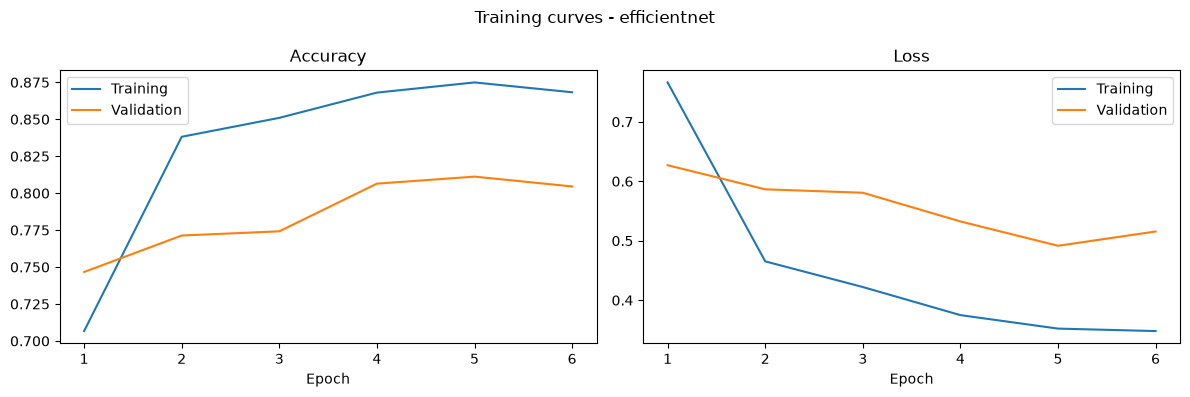

In [13]:
model = build_efficientnet()      # fresh model
history_df, seconds = train_model(model, train_ds, val_ds, "efficientnet", epochs=6)
print(f"Training took {seconds/60:.1f} minutes, {len(history_df)} epochs")
evaluation.plot_training_curves(history_df, "efficientnet")

Validation: {'accuracy': 0.811, 'precision_macro': 0.824, 'recall_macro': 0.81, 'f1_macro': 0.797, 'roc_auc_ovr': 0.967}
Test:       {'accuracy': 0.755, 'precision_macro': 0.762, 'recall_macro': 0.755, 'f1_macro': 0.731, 'roc_auc_ovr': 0.944}
              precision    recall  f1-score   support

      glioma      0.761     0.670     0.713       400
  meningioma      0.791     0.378     0.511       400
     notumor      0.788     0.988     0.877       400
   pituitary      0.709     0.985     0.824       400

    accuracy                          0.755      1600
   macro avg      0.762     0.755     0.731      1600
weighted avg      0.762     0.755     0.731      1600



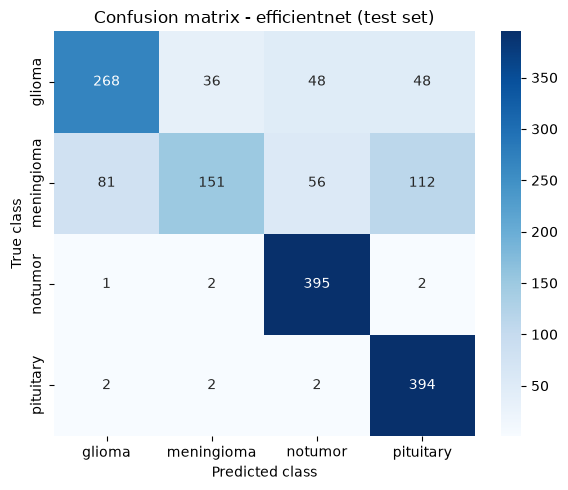

                    mean  count
class      is_512              
glioma     False   0.079     76
           True    0.809    324
meningioma False   0.060    117
           True    0.509    283
notumor    False   0.987    397
           True    1.000      3
pituitary  False   1.000      8
           True    0.985    392


In [14]:
MODEL_NAME = "efficientnet"

y_val, pred_val, prob_val = metrics.predict_dataset(model, val_ds)
y_test, pred_test, prob_test = metrics.predict_dataset(model, test_ds)
val_metrics = metrics.compute_metrics(y_val, pred_val, prob_val)
test_metrics = metrics.compute_metrics(y_test, pred_test, prob_test)
print("Validation:", {k: round(v, 3) for k, v in val_metrics.items()})
print("Test:      ", {k: round(v, 3) for k, v in test_metrics.items()})
print(metrics.get_classification_report(y_test, pred_test))
plot_confusion_matrix(y_test, pred_test, MODEL_NAME)
evaluation.save_results(MODEL_NAME, val_metrics, test_metrics, seconds,
                        history_df, model.count_params())

check = test_df.copy()
check["correct"] = (y_test == pred_test)
check["is_512"] = (check["width"] == 512) & (check["height"] == 512)
print(check.groupby(["class", "is_512"])["correct"].agg(["mean", "count"]).round(3))